# 3 targets: SM, ET and Q

When training I will have 3 losses to optmize upon. Two of them are computed cell by cell, whilst the $ Q $ should be computed over the entire upstream basin cells. 

Now working only with 1 timeseries of discharge per basin. It is better that it comes form the outlet of the basin so that I can compute the combined loss for all the upstream cells. Otherwise some cells would be out and should not partecipate in the computation of the loss. like

loss = sm_et_q_loss (inside basin) + sm_et_loss (outside basin)

It does not make much sense. 

The other idea is to compute before hand the sampling error as we subsample the domain. So that we have a sm + et + err -> q

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
import xarray as xr
from pathlib import Path
import os
import random

from torch import nn

from sklearn.metrics import mean_squared_error
from hython.preprocess import reshape, apply_normalization
from hython.datasets.datasets import LSTMDataset
from hython.train_val import train_val
from hython.sampler import RegularIntervalSampler, SpaceSampler
from hython.metrics import mse_metric
from hython.losses import RMSELoss

import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset

from hython.utils import missing_location_idx, reconstruct_from_missing, load
from hython.models.lstm import CustomLSTM

# viz
import matplotlib.pyplot as plt
from hython.viz import plot_sampler
from hython.utils import predict, prepare_for_plotting
from hython.viz import map_bias, map_pbias, map_pearson, map_at_timesteps, ts_compare, plot_sampler

def set_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(43)

/home/iacopo/.local/build/mambaforge/envs/dl-pytorch/lib/python3.11/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
dynamic_names = ["precip", "pet", "temp"]
static_names = [ 'thetaS', 'thetaR', 'RootingDepth', 'Swood','KsatVer'] #, 'TT', 'KsatHorFrac'] 
target_names = [ "vwc","actevap" ] # "q_river"]

fn_forcings =  "forcings.nc"  # 'inmaps_eobs_eobsd_makkink_86400_2015_2019.nc' 
fn_params = "staticmaps.nc"
fn_targets = "output.nc"


timeslice = slice("2016-01-01","2020-12-31")

In [5]:
wflow_model = "datademo" #"adg1km_eobs" #"datademo" # "alps1km_eobs" # "alps1km_cerra", 

wd = Path("../data") / wflow_model

fp_dynamic_forcings = wd / fn_forcings 
fp_wflow_static_params = wd / fn_params
fp_target = wd / fn_targets

forcings = xr.open_dataset(fp_dynamic_forcings)
params = xr.open_dataset(fp_wflow_static_params)
targets = xr.open_dataset(fp_target).isel(lat=slice(None, None, -1))

In [6]:
# wflow_model =  "adg1km_eobs" # "alps1km_eobs" #

# wd = Path("/mnt/CEPH_PROJECTS/InterTwin/Wflow/models") / wflow_model

# input_dir_path = Path('/mnt/CEPH_PROJECTS/InterTwin/Wflow/models') / wflow_model
# output_dir_path = Path('/mnt/CEPH_PROJECTS/InterTwin/surrogate/')
# model_weigths_path = output_dir_path / "model_weights"
# surrogate_input_path = Path("/mnt/CEPH_PROJECTS/InterTwin/hydrologic_data/surrogate_training")

# forcings = xr.open_dataset(input_dir_path / fn_forcings , chunks= {"time":100})
# params = xr.open_dataset(input_dir_path / fn_params ,  chunks= {"time":100}).sel(layer=1)
# targets = xr.open_dataset(input_dir_path / "run_default" / fn_targets, chunks= {"time":100}).sel(layer=1).isel(lat=slice(None, None, -1))

In [7]:
forcings = forcings[dynamic_names]
params = params[static_names]
targets = targets[target_names] 

In [8]:
try:
    forcings = forcings.rename({"latitude":"lat", "longitude":"lon"})
    params = params.rename({"latitude":"lat", "longitude":"lon"})
except:
    pass

In [9]:
# training 

spatial_batch_size = 128
temporal_sampling_size = 150 
seq_length = 260 # days

# model 

hidden_size = 32

model_params={
    "input_size": 3, #number of dynamic predictors - user_input
    "hidden_size": hidden_size, # user_input
    "output_size": len(target_names), # number_target - user_input
    "number_static_predictors": len(static_names), #number of static parameters - user_input 

}

## The used device for training
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [10]:
remove_lakes = True

if remove_lakes:
    mask_lakes = (targets.mean(dim = "time")["actevap"] == 0).astype(np.bool_)
    targets = targets.where(~mask_lakes, np.nan)
    forcings = forcings.where(~mask_lakes, np.nan)
    params = params.where(~mask_lakes, np.nan)


if timeslice:
    forcings = forcings.sel(time=timeslice)
    targets = targets.sel(time=timeslice)

In [11]:
# UNCOMMENT IF NOT LOADING PREPROCESSED INPUTS

#reshape for training

Xd, Xs, Y  = reshape(
                   forcings, 
                   params, 
                   targets
                   )

#Define the 2D missing values mask. Sampling 

missing_mask = np.isnan(params[static_names[0]]).values

# UNCOMMENT TO SAVE
# np.savez_compressed( surrogate_input_path / f"{wflow_model}", Xd=Xd, Xs=Xs, Y=Y, missing_mask = missing_mask)

dynamic:  (1452, 1827, 3)  => (GRIDCELL, TIME, FEATURE)
static:  (1452, 5)  => (GRIDCELL, FEATURE)
target:  (1452, 1827, 2)  => (GRIDCELL, TIME, TARGET)


In [12]:
intervals = (5, 5) # every n km
train_origin = (0, 0)
val_origin = (3, 3)

spatial_train_sampler = RegularIntervalSampler(intervals = intervals, origin = train_origin)
spatial_val_sampler = RegularIntervalSampler(intervals = intervals, origin = val_origin) 

In [13]:
data2d  = forcings.to_dataarray().transpose("lat","lon", "time", "variable")

sampler_train_meta = spatial_train_sampler.sampling_idx(data2d, missing_mask)
sampler_val_meta = spatial_val_sampler.sampling_idx(data2d, missing_mask)

In [14]:
_, d_m, d_std = apply_normalization(Xd[sampler_train_meta.idx_sampled_1d_nomissing], type = "spacetime", how ='standard')
_, s_m, s_std = apply_normalization(Xs[sampler_train_meta.idx_sampled_1d_nomissing], type = "space", how ='standard')
_, y_m, y_std = apply_normalization(Y[sampler_train_meta.idx_sampled_1d_nomissing], type = "spacetime", how ='standard')

In [15]:
Xd = apply_normalization(Xd, type="spacetime", how="standard", m1 = d_m, m2 = d_std)
Xs = apply_normalization(Xs, type="space", how="standard",  m1 = s_m, m2 = s_std)
Y = apply_normalization(Y, type="spacetime",how="standard", m1 = y_m, m2 = y_std)

In [16]:
Xs = torch.Tensor(Xs)
Xd = torch.Tensor(Xd)
Y = torch.Tensor(Y)

Xs.shape, Xd.shape, Y.shape

(torch.Size([1452, 5]),
 torch.Size([1452, 1827, 3]),
 torch.Size([1452, 1827, 2]))

In [17]:
# init datasets
dataset = LSTMDataset(Xd, Y) #, Xs)

In [18]:
train_sampler = SpaceSampler(dataset, num_samples=100, sampling_indices = sampler_train_meta.idx_sampled_1d_nomissing.tolist())
valid_sampler = SpaceSampler(dataset, num_samples=100, sampling_indices = sampler_val_meta.idx_sampled_1d_nomissing.tolist())

In [19]:
train_loader = DataLoader(dataset, batch_size=spatial_batch_size, shuffle=False, sampler = train_sampler) # implement shuffling in the sampler!
val_loader = DataLoader(dataset, batch_size=spatial_batch_size, shuffle=False, sampler = valid_sampler)

In [22]:
model = CustomLSTM(model_params)
model = model.to(device)
model

CustomLSTM(
  (fc0): Linear(in_features=8, out_features=32, bias=True)
  (lstm): LSTM(32, 32, batch_first=True)
  (fc1): Linear(in_features=32, out_features=2, bias=True)
)

In [591]:
class SMEP(nn.Module):
   ...:     def __init__(self):
   ...:         super(SMEP, self).__init__()
   ...:         self.distr = nn.Linear(8,2, bias=False)
    
   ...:         self.linear = nn.Linear(2,1, bias=False)
    
   ...:     def forward(self, X):
   ...:         sm_evap = torch.stack([self.distr(time) for time in X ])#;print(sm_evap.shape)
   ...:         #q1 = torch.mean(sm_evap,0)#;print(q1.shape) n batches -> (20,2)
   ...:         #q = self.linear(q1)#;print(q.shape) smet -> (20,1)
   ...:         return sm_evap

In [592]:
class Dis(nn.Module):
    def __init__(self):
        super(Dis, self).__init__()
        self.linear = nn.Linear(2,1, bias=False)
    def forward(self, smet):
        q1 = torch.mean(smet, 0)
        #;print(q1.shape)  #n batches -> (20,2)
        q = self.linear(q1)
        #;print(q.shape) #smet -> (20,1)    
        return q
        

In [593]:
model1 = SMEP()
model2 = Dis()

In [594]:
#q, smet = model(P)

In [595]:
# # Create DataLoader
#train_dataset = TensorDataset(P, Y)

#train_loader = DataLoader(train_dataset, batch_size=3, shuffle=True)

In [596]:
import itertools

criterion = nn.MSELoss()
optimizer = optim.Adam(itertools.chain(model1.parameters(), model2.parameters()), lr=0.001)

# Training loop
num_epochs = 1000

qq = []
smsm = []

for epoch in range(num_epochs):
    model1.train()
    model2.train()
    smet_all = []
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        # Forward pass
        smet = model1(batch_X)
        smet_all.append(smet)
        #print(batch_y[...,[2]].shape,batch_y[...,[0,1]].shape)
        
        #loss_q = criterion(q, batch_y[[2]])
        #loss_smet = criterion(smet, batch_y[...,[0,1]])

        #loss = loss_q + loss_smet
        # Backward pass
        #loss.backward()

        # Update weights
        #optimizer.step()
    smetall = torch.cat(smet_all)

    q = model2(smetall)
    #print(q)
    #print(train_loader.dataset.tensors[1][...,[2]].shape)
    
    loss_q = criterion(q,train_loader.dataset.y[1][...,[2]])
    loss_smet = criterion(smetall, train_loader.dataset.y[1][...,[0,1]] )

    loss = loss_q + loss_smet

    loss.backward()

    optimizer.step()
    
    #print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}')

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1827x3 and 8x2)

In [540]:
def predict(model1, model2, input_data, batch_size=3):
    model1.eval()
    model2.eval()
    
    # with torch.no_grad():
    #     input_tensor = torch.tensor(input_data, dtype=torch.float32)
    #     # Ensure the input tensor has the correct shape (batch_size, input_channels, height, width)
    #     # if len(input_tensor.shape) == 3:
    #     #     input_tensor = input_tensor.unsqueeze(0)
        
    #     smet = model(input_tensor)
    with torch.no_grad():

        SMET = []
        for i in range(0,input_data.shape[0], batch_size):
            
            smet = torch.Tensor(input_data[i:(i+batch_size)])
            
            SMET.append(
                model1(smet)
                )
        smetall = torch.cat(SMET)

        q = model2(smetall)

    return q.numpy(), smetall.numpy()

In [541]:
pq, psmet = predict(model1, model2, P)

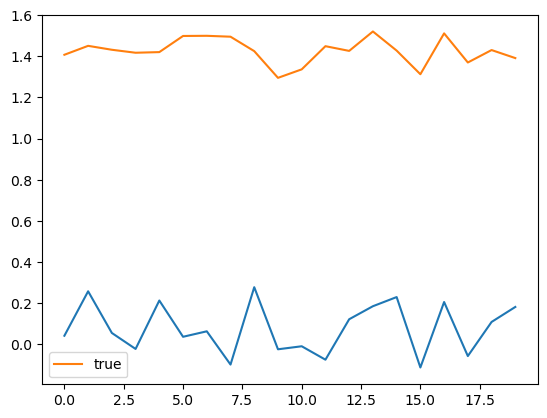

In [542]:
plt.plot(pq)
plt.plot(Q[0], label = "true")
plt.legend()

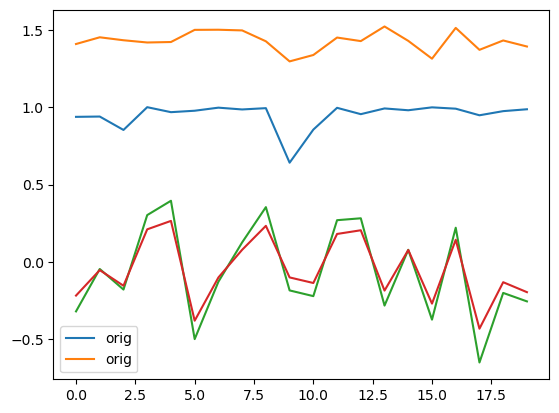

In [543]:
plt.plot(Y[...,[1,2]].numpy()[10], label="orig")
plt.plot(psmet[10])
plt.legend()